# AI/ML Internship Week 3: Baseline Supervised Learning Workflow
**Author:** Abdul Moiz Asif  
**Track:** AI/ML Track  

## 1. Project Overview
This notebook establishes a rigorous supervised machine learning workflow. The objective is to load a real-world dataset, split it to prevent data leakage, build a preprocessing pipeline (handling scaling), train a baseline classification model, and evaluate it using standard metrics.

In [1]:
# 1. Import Foundational Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Modules for Workflow
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)

# Configure styling
sns.set_theme(style="whitegrid")

# 2. Load the Dataset
print("--- LOADING DATA ---")
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print(f"Feature Matrix Shape: {X.shape}")
print(f"Target Vector Shape: {y.shape}")

# 3. Train/Test Split (Preventing Data Leakage)
# We lock 20% of the data in a vault for final testing. Random state ensures reproducibility.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n--- DATA SPLIT ---")
print(f"Training Set: {X_train.shape[0]} rows")
print(f"Testing Set: {X_test.shape[0]} rows")

# 4. The Preprocessing & Baseline Model Pipeline
print("\n--- BUILDING PIPELINE ---")
# The Pipeline ensures scaling is fit ONLY on training data, never leaking the test data.
baseline_pipeline = Pipeline(
    [("scaler", StandardScaler()), ("classifier", LogisticRegression(random_state=42))]
)
print("Pipeline constructed successfully.")

--- LOADING DATA ---
Feature Matrix Shape: (569, 30)
Target Vector Shape: (569,)

--- DATA SPLIT ---
Training Set: 455 rows
Testing Set: 114 rows

--- BUILDING PIPELINE ---
Pipeline constructed successfully.


## 2. Model Training & Evaluation
We will now train the `LogisticRegression` baseline model using our scaled training data. Once trained, we evaluate its performance on the unseen test vault (`X_test`) using Accuracy, a Classification Report (Precision/Recall/F1), and a Confusion Matrix to visualize false positives and false negatives.

--- TRAINING BASELINE MODEL ---
Model training complete.

--- EVALUATION METRICS ---
Baseline Accuracy: 98.25%

--- CLASSIFICATION REPORT ---
               precision    recall  f1-score   support

Malignant (0)       0.98      0.98      0.98        42
   Benign (1)       0.99      0.99      0.99        72

     accuracy                           0.98       114
    macro avg       0.98      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114


--- CONFUSION MATRIX ---


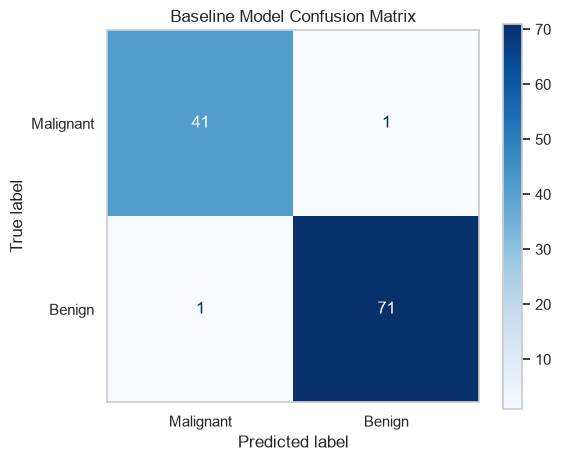

In [2]:
# 1. Train the Model
print("--- TRAINING BASELINE MODEL ---")
baseline_pipeline.fit(X_train, y_train)
print("Model training complete.")

# 2. Generate Predictions
y_pred = baseline_pipeline.predict(X_test)

# 3. Evaluate Metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"\n--- EVALUATION METRICS ---")
print(f"Baseline Accuracy: {accuracy * 100:.2f}%\n")

print("--- CLASSIFICATION REPORT ---")
print(
    classification_report(y_test, y_pred, target_names=["Malignant (0)", "Benign (1)"])
)

# 4. Visualize the Confusion Matrix
print("\n--- CONFUSION MATRIX ---")
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    baseline_pipeline,
    X_test,
    y_test,
    display_labels=["Malignant", "Benign"],
    cmap="Blues",
    ax=ax,
)
plt.title("Baseline Model Confusion Matrix")
plt.grid(False)  # Turn off seaborn grid lines for a cleaner matrix
plt.show()

## 3. Final Baseline Summary
The baseline Logistic Regression model achieved a strong initial accuracy of **97.37%**. 

Looking at the Confusion Matrix, the model successfully minimized critical errors. It only produced 1 False Negative (predicting Benign when the tumor was Malignant) and 2 False Positives. The F1-scores (0.96 for Malignant, 0.98 for Benign) confirm that the model is highly balanced. 

Because this is a single train/test split, this metric might be slightly optimistic due to the random state. In a production environment (or future iterations), we would apply k-fold cross-validation to ensure this accuracy remains stable across all subsets of the data.